# Text Classification with Naive Bayes
---

## 1. PROBLEM DESCRIPTION

### Problem Statement
Given a raw SMS message, predict whether it is **spam** or a legitimate message (**ham**). This is a supervised binary text classification problem.

### Goal
Build a robust NLP pipeline that accurately classifies SMS messages as spam or ham, enabling automated filtering systems to protect users from unsolicited and potentially fraudulent messages.

### Features Description
| Feature | Type | Description |
|---------|------|-------------|
| `Message` | Text (string) | The raw SMS message content written by the sender |

### Target Variable
- **`Category`** — Whether the SMS is spam or ham.

### Metrics
| Metric | Description |
|--------|-------------|
| **PR-AUC** | Primary metric — area under the Precision-Recall curve; best suited for imbalanced classification |
| **F1-Score** | Harmonic mean of Precision and Recall; balances the cost of false positives and false negatives |
| **Recall** | Fraction of actual spam correctly caught; high recall = fewer spam messages slip through |
| **Precision** | Fraction of predicted spam that is truly spam; high precision = fewer legitimate messages wrongly flagged |
| **ROC-AUC** | Overall discriminative power across all thresholds |

---
## 2. Import Libraries & Config

In [1]:
# ── Core ──
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import joblib
import re
import itertools

# ── Visualisation ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── NLP ──
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ── Feature Extraction ──
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Model Selection ──
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, cross_val_predict

# ── Models ──
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB

# ── Preprocessing ──
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# ── Metrics ──
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve,
)

# ── Config ──
EN_STOPWORDS = set(stopwords.words('english'))
RANDOM_STATE = 42
CV_FOLDS     = 5
MODEL_PATH = '../model/best_spam_model.pkl'

---
## 3. Data Loading and Discovery

In [2]:
df = pd.read_csv('../data/spam.csv')
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head(10)

Rows: 5,572  |  Columns: 2


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [3]:
# Null values
null_counts = df.isnull().sum()
print(f"\nNull value counts:\n{null_counts}")


Null value counts:
Category    0
Message     0
dtype: int64


In [4]:
n_dup = df.duplicated().sum()
print(f"Duplicated rows: {n_dup}")

Duplicated rows: 415


---

**Initial preprocessing for EDA; the rest will follow after EDA**

In [5]:
# ── Remove Duplicates ──
df = df.drop_duplicates()
print(f"Rows remaining: {len(df):,}")

Rows remaining: 5,157


---
## 4. EDA

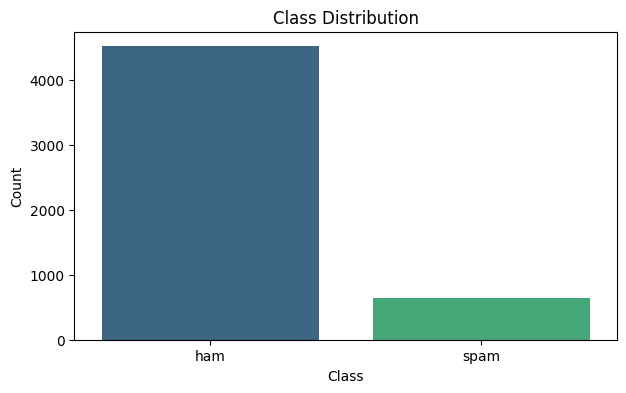

Class counts:
 Category
ham     4516
spam     641
Name: count, dtype: int64

Imbalance ratio: 7.05


In [6]:
class_counts = df['Category'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

plt.figure(figsize=(7, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

print('Class counts:\n',class_counts)
print(f'\nImbalance ratio: {imbalance_ratio:.2f}')

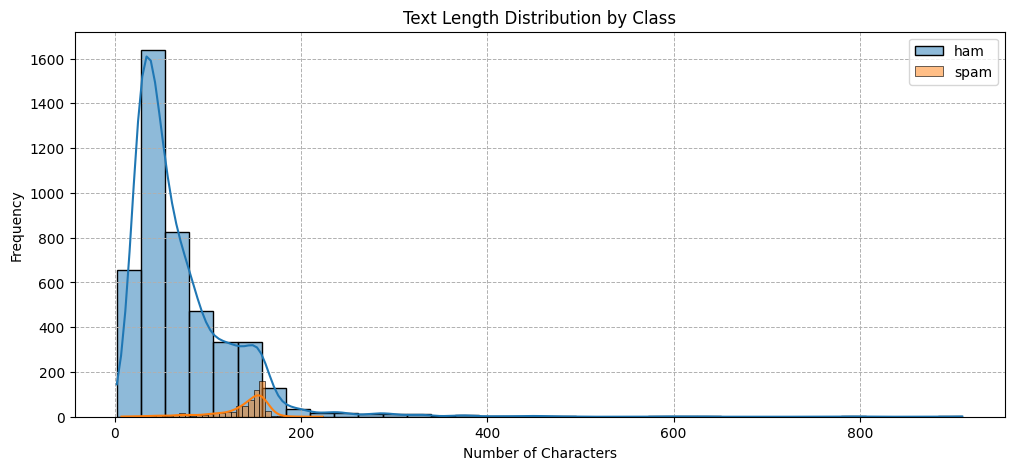

In [7]:
df['text_len'] = df['Message'].str.len()

plt.figure(figsize=(12, 5))
for c in df['Category'].unique():
    sns.histplot(df.loc[df['Category'] == c, 'text_len'], bins=35, kde=True, label=c)
    
plt.title('Text Length Distribution by Class')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.grid(linestyle='--', linewidth=0.7)
plt.legend()
plt.show()

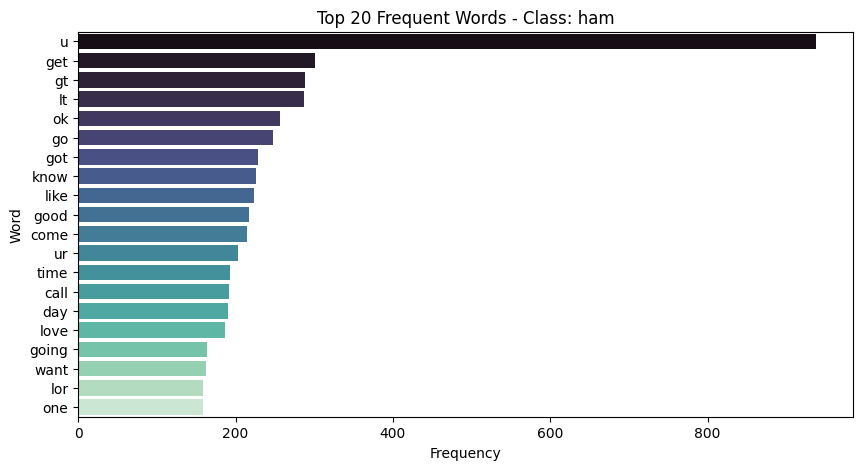

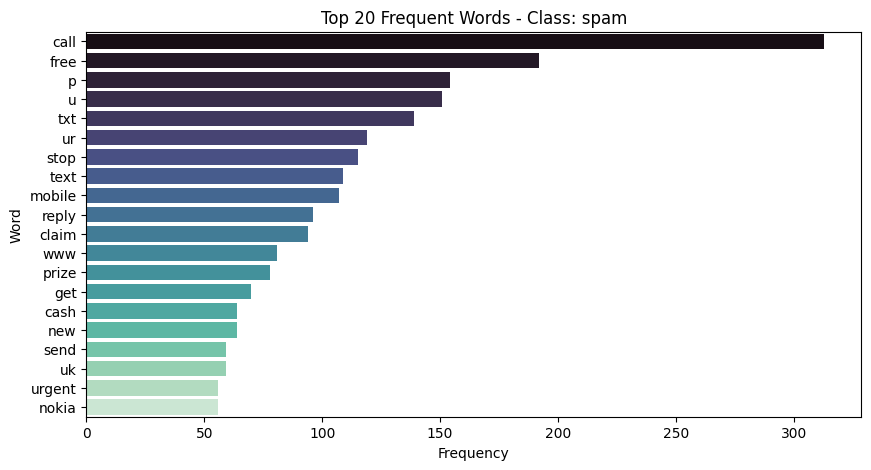

In [8]:
def simple_tokenize(s):
    s = re.sub(r'[^a-zA-Z\s]', ' ', str(s).lower())
    return [w for w in s.split() if w and w not in EN_STOPWORDS]

for c in df['Category'].unique():
    tokens = []
    for msg in df.loc[df['Category'] == c, 'Message']:
        tokens.extend(simple_tokenize(msg))
        
    top_words = pd.Series(tokens).value_counts().head(20)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_words.values, y=top_words.index, palette='mako')
    plt.title(f'Top 20 Frequent Words - Class: {c}')
    plt.xlabel('Frequency')
    plt.ylabel('Word')
    plt.show()

---
## 5. Preprocessing

In [9]:
# Target encoding
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

In [10]:
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()

# Text preprocessing Function
def preprocess_text(text, normalize):
    text = str(text).lower()
    #remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    #remove digits
    text = re.sub(r'\d+', ' ', text)
    
    tokens = word_tokenize(text)
    #remove stop words
    tokens = [t for t in tokens if t not in EN_STOPWORDS]

    if normalize == 'stem':
        tokens = [STEMMER.stem(t) for t in tokens]
    elif normalize == 'lemma':
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    else:
        raise ValueError("normalize must be 'stem' or 'lemma'")

    cleaned = ' '.join(tokens)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    
    return cleaned

def preprocess_stem(X):
    return X.apply(lambda t: preprocess_text(t, normalize='stem'))

def preprocess_lemma(X):
    return X.apply(lambda t: preprocess_text(t, normalize='lemma'))

PREP_FN = {'stem': preprocess_stem, 'lemma': preprocess_lemma}

---
## 6. Train/Test Split

In [11]:
X = df['Message']
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

---
## 7. Experiment Grid & Search

In [12]:
# Define hyperparameter search grids

preprocess_modes = ['stem', 'lemma']
max_features_grid = [5000, 10000, None]
count_binary_grid = [False, True]
alpha_grid = [0.01, 0.1, 1.0]

vectorizer_families = [
    {'name': 'count', 'analyzer': 'word', 'ngram_range': (1, 1)},
    {'name': 'count', 'analyzer': 'word', 'ngram_range': (1, 2)},
    {'name': 'count', 'analyzer': 'char', 'ngram_range': (2, 4)},
    {'name': 'tfidf', 'analyzer': 'word', 'ngram_range': (1, 1)},
    {'name': 'tfidf', 'analyzer': 'word', 'ngram_range': (1, 2)},
    {'name': 'tfidf', 'analyzer': 'word', 'ngram_range': (1, 2), 'sublinear_tf': True},
    {'name': 'tfidf', 'analyzer': 'char', 'ngram_range': (2, 4)},
]

nb_variants = {
    'MultinomialNB': MultinomialNB,
    'ComplementNB': ComplementNB,
    'BernoulliNB': BernoulliNB,
}

VALID_PAIRINGS = {
    'MultinomialNB': ['count', 'tfidf'],
    'ComplementNB':  ['count', 'tfidf'],
    'BernoulliNB':   ['count'],
}

In [13]:
def build_vectorizer(cfg, max_features, count_binary):
    if cfg['name'] == 'count':
        return CountVectorizer(
            analyzer=cfg['analyzer'],
            ngram_range=cfg['ngram_range'],
            max_features=max_features,
            binary=count_binary
        )
        
    if cfg['name'] == 'tfidf':
        return TfidfVectorizer(
            analyzer=cfg['analyzer'],
            ngram_range=cfg['ngram_range'],
            max_features=max_features,
            sublinear_tf=cfg.get('sublinear_tf', False)
        )

In [14]:
#pairing each family with its valid hyperparameter combinations

vec_expanded = []
for cfg in vectorizer_families:
    
    if cfg['name'] == 'count':
        for mf, binary in itertools.product(max_features_grid, count_binary_grid):
            vec_expanded.append((cfg, mf, binary))

    if cfg['name'] == 'tfidf':
        for mf in max_features_grid:
            vec_expanded.append((cfg, mf, False))

all_experiments = [
    (prep_mode, (vec_cfg, mf, binary), (nb_name, nb_cls), alpha)
    for prep_mode, (vec_cfg, mf, binary), (nb_name, nb_cls), alpha
    in itertools.product(preprocess_modes, vec_expanded, nb_variants.items(), alpha_grid)
    if vec_cfg['name'] in VALID_PAIRINGS[nb_name]
]

print('Total experiments:', len(all_experiments))

Total experiments: 468


In [15]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
}

results = []

In [16]:
# Run all experiments with cross-validation

for prep_mode, (vec_cfg, max_feat, count_binary), (nb_name, nb_cls), alpha in all_experiments:
    
    pipe = Pipeline([
        ('prep', FunctionTransformer(PREP_FN[prep_mode])),
        ('vec', build_vectorizer(vec_cfg, max_feat, count_binary)),
        ('clf', nb_cls(alpha=alpha))
    ])
    
    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        scoring = scoring,
        n_jobs = -1,
    )

    row = {
        'preprocess_mode': prep_mode,
        'vectorizer_name': vec_cfg['name'],
        'analyzer': vec_cfg['analyzer'],
        'ngram_range': vec_cfg['ngram_range'],
        'sublinear_tf': vec_cfg.get('sublinear_tf', False),
        'max_features': max_feat,
        'count_binary': count_binary if vec_cfg['name'] == 'count' else np.nan,
        'nb_variant': nb_name,
        'alpha': alpha,
        'pr_auc': np.mean(cv_out['test_pr_auc']),
        'pr_auc_std':      np.std(cv_out['test_pr_auc']),
        'precision': np.mean(cv_out['test_precision']),
        'recall': np.mean(cv_out['test_recall']),
        'f1': np.mean(cv_out['test_f1']),
        'roc_auc': np.mean(cv_out['test_roc_auc']),
        'accuracy': np.mean(cv_out['test_accuracy'])
    }
    
    results.append(row)

In [17]:
#Rank experiments by PR-AUC and extract best config
results_df = pd.DataFrame(results)
ranked = results_df.sort_values('pr_auc', ascending=False).reset_index(drop=True)
print('Primary metric: PR-AUC')
display(ranked.head(10))

best_config = ranked.iloc[0].to_dict()
print('Best configuration:')
for k, v in best_config.items():
    print(f'{k}: {v}')

Primary metric: PR-AUC


,preprocess_mode,vectorizer_name,analyzer,ngram_range,sublinear_tf,max_features,count_binary,nb_variant,alpha,pr_auc,pr_auc_std,precision,recall,f1,roc_auc,accuracy
0,stem,count,word,"(1, 2)",False,NaN,False,BernoulliNB,0.1,0.977118,0.007736,0.997701,0.875176,0.932362,0.990451,0.984242
1,stem,count,word,"(1, 2)",False,NaN,True,BernoulliNB,0.1,0.977118,0.007736,0.997701,0.875176,0.932362,0.990451,0.984242
2,lemma,count,word,"(1, 2)",False,NaN,False,BernoulliNB,0.1,0.976482,0.007534,0.997701,0.869313,0.929013,0.990428,0.983515
3,lemma,count,word,"(1, 2)",False,NaN,True,BernoulliNB,0.1,0.976482,0.007534,0.997701,0.869313,0.929013,0.990428,0.983515
4,stem,count,word,"(1, 2)",False,10000.0,False,BernoulliNB,0.1,0.974916,0.006701,0.997701,0.877099,0.933416,0.989860,0.984485
5,stem,count,word,"(1, 2)",False,5000.0,False,BernoulliNB,1.0,0.974845,0.007688,1.000000,0.764002,0.865693,0.990749,0.970667
6,stem,count,word,"(1, 2)",False,10000.0,True,BernoulliNB,0.1,0.974450,0.006838,0.997727,0.877118,0.933486,0.989782,0.984485
7,stem,count,word,"(1, 2)",False,5000.0,False,BernoulliNB,0.1,0.974208,0.006950,0.995553,0.871274,0.929209,0.989708,0.983515
8,lemma,count,word,"(1, 2)",False,5000.0,False,BernoulliNB,1.0,0.974207,0.007559,1.000000,0.754236,0.859270,0.990908,0.969455
9,lemma,count,word,"(1, 2)",False,5000.0,True,BernoulliNB,1.0,0.974166,0.007581,1.000000,0.754236,0.859270,0.991288,0.969455


Best configuration:
preprocess_mode: stem
vectorizer_name: count
analyzer: word
ngram_range: (1, 2)
sublinear_tf: False
max_features: nan
count_binary: False
nb_variant: BernoulliNB
alpha: 0.1
pr_auc: 0.9771179539017474
pr_auc_std: 0.007736144759803157
precision: 0.9977011494252874
recall: 0.8751760898534172
f1: 0.9323624114107798
roc_auc: 0.9904507560259568
accuracy: 0.9842424242424241


---
## 8. Results Analysis

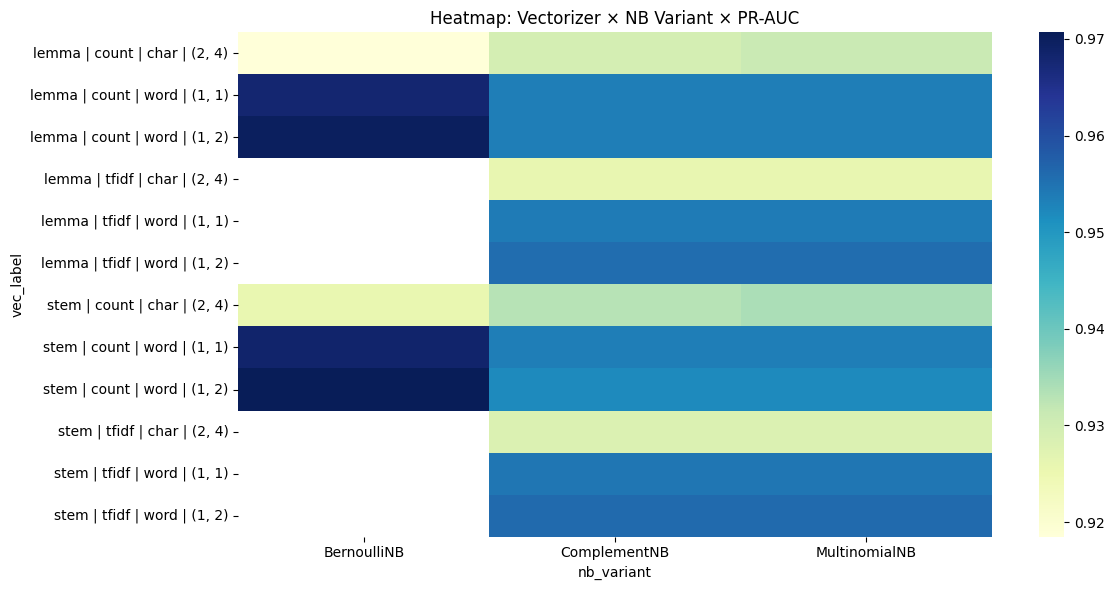

In [18]:
heat = results_df.copy()

heat['vec_label'] = heat['preprocess_mode'] + ' | ' + heat['vectorizer_name'] + ' | ' + heat['analyzer'] + ' | ' + heat['ngram_range'].astype(str)
pivot = heat.pivot_table(index='vec_label', columns='nb_variant', values='pr_auc', aggfunc='mean')
plt.figure(figsize=(12, max(6, len(pivot)*0.35)))
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title('Heatmap: Vectorizer × NB Variant × PR-AUC')
plt.tight_layout()
plt.show()

---
## 9. Final Model Training & Evaluation

In [19]:
def instantiate_from_best(row):
    cfg = {
        'name': row['vectorizer_name'],
        'analyzer': row['analyzer'],
        'ngram_range': row['ngram_range'],
        'sublinear_tf': bool(row.get('sublinear_tf', False))
    }
    
    count_binary = bool(row['count_binary']) if row['vectorizer_name'] == 'count' and not pd.isna(row['count_binary']) else False
    max_feat = None if pd.isna(row['max_features']) else row['max_features']
    vec = build_vectorizer(cfg, max_feat, count_binary)
    clf = nb_variants[row['nb_variant']](alpha=float(row['alpha']))
    prep = FunctionTransformer(PREP_FN[row['preprocess_mode']])
    return Pipeline([('prep', prep), ('vec', vec), ('clf', clf)])

best_pipeline = instantiate_from_best(best_config)
best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 FunctionTransformer(func=<function preprocess_stem at 0x000001F9A9FDCB80>)),
                ('vec', CountVectorizer(ngram_range=(1, 2))),
                ('clf', BernoulliNB(alpha=0.1))])

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       904
           1       1.00      0.87      0.93       128

    accuracy                           0.98      1032
   macro avg       0.99      0.93      0.96      1032
weighted avg       0.98      0.98      0.98      1032

ROC AUC: 0.9896
PR-AUC:  0.9700



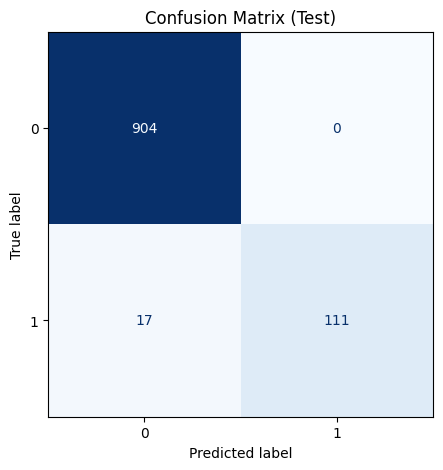

In [20]:
y_test_pred = best_pipeline.predict(X_test)
y_test_prob = best_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred))
print(f"ROC AUC: {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_test_prob):.4f}")
print()

cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix (Test)')
plt.show()

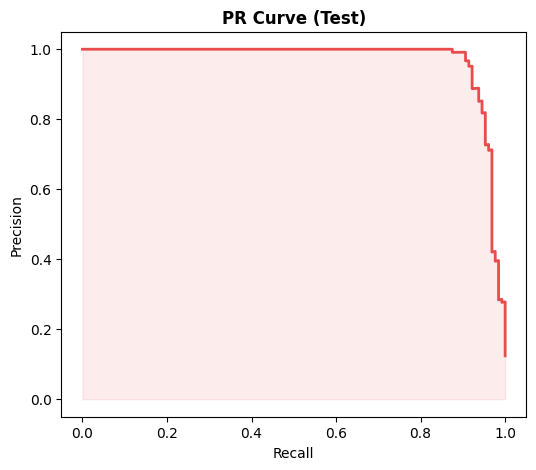

In [21]:
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color='#E84C4C', lw=2,)
plt.fill_between(recall, precision, alpha=0.1, color='#E84C4C')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve (Test)', fontweight='bold')
plt.show()

---
## 10. Error Analysis

In [22]:
if hasattr(best_pipeline.named_steps['clf'], 'predict_proba'):
    proba = best_pipeline.predict_proba(X_test)
    conf = proba.max(axis=1)
else:
    conf = np.full(len(X_test), np.nan)

err_df = pd.DataFrame({
    'text': X_test.values,
    'true_label': y_test.values,
    'pred_label': y_test_pred,
    'confidence': conf
})
mis = err_df[err_df['true_label'] != err_df['pred_label']].sort_values('confidence', ascending=False)
display(mis.head(20))

,text,true_label,pred_label,confidence
283,TBS/PERSOLVO. been chasing us since Sept for£3...,1,0,1.000000
306,Hello darling how are you today? I would love ...,1,0,1.000000
354,Hi I'm sue. I am 20 years old and work as a la...,1,0,1.000000
1027,In The Simpsons Movie released in July 2007 na...,1,0,1.000000
723,#ERROR!,1,0,1.000000
803,You can donate £2.50 to UNICEF's Asian Tsunami...,1,0,1.000000
952,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,0,1.000000
848,dating:i have had two of these. Only started a...,1,0,1.000000
582,Want explicit SEX in 30 secs? Ring 02073162414...,1,0,1.000000
247,Missed call alert. These numbers called but le...,1,0,1.000000


---
## 11. Save Best Model

In [23]:
artifact = {
    'model': best_pipeline,
    'best_config': best_config,
    'test_metrics': {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'precision': precision_score(y_test, y_test_pred),
        'recall': recall_score(y_test, y_test_pred),
        'f1': f1_score(y_test, y_test_pred),
        'roc_auc': roc_auc_score(y_test, y_test_prob),
        'pr_auc': average_precision_score(y_test, y_test_prob),
        'classification_report': classification_report(y_test, y_test_pred, output_dict=True),
    },
    'confusion_matrix': cm,
    'class_labels': np.unique(y_test).tolist(),
}

joblib.dump(artifact, MODEL_PATH)

['../model/best_spam_model.pkl']

---
# DONE
---